
# Titanic Survival Analysis  
 
This project analyzes the Titanic dataset to identify the key factors that influenced passenger survival.  
The goal is to extract structured insights using professional EDA techniques suitable for a placement portfolio.



## 1. Business Problem Statement

The objective of this analysis is to understand which passenger attributes (such as gender, class, age, fare, and family size) had the greatest impact on survival during the Titanic disaster.

We aim to extract meaningful insights that explain survival patterns using structured exploratory data analysis.


In [112]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Dataset

In [113]:

df = pd.read_csv('Titanic-Dataset.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Dataset Overview

In [114]:
df.shape

(891, 12)

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [116]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



## 4. Initial Observations from Raw Data

- Dataset contains missing values.
- Cabin has excessive missing data.
- Mix of numerical and categorical features.
- Target variable (Survived) appears slightly imbalanced.


## 5. Missing Value Analysis

In [117]:

df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Handling Missing Values
### Age
	•	Age has some very small and very large values
	•	If we take average (mean), those extreme ages can disturb the result
	•	Median gives the middle value, so it is more balanced
	•	It does not get affected much by very high or very low ages
	•	It keeps the data more realistic
### Embark
	•	Embarked is not a number, it is a category (S, C, Q)
	•	We cannot calculate average for letters
	•	Mode means the most common value
	•	Filling missing values with the most common port keeps the data natural



In [118]:

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

## 6. Dropping Irrelevant Columns
1. Cabin → 687 missing values (~77%). Too sparse to be reliable.
2. PassengerId → Unique identifier, no predictive value.
3. Name → High-cardinality text column.
4. Ticket → Mostly unique values.

Dropping these columns does not remove meaningful predictive numerical information.


In [119]:

df = df.drop(columns=['PassengerId', 'Name', 'Ticket','Cabin'])
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 7. Encoding Categorical Variables

In [120]:

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


### Label Encoding Code

In [121]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode Sex column
df['Sex_male']=le.fit_transform(df['Sex_male'])

# Encode Embarked column
df['Embarked_Q']=le.fit_transform(df['Embarked_Q'])
df['Embarked_S']=le.fit_transform(df['Embarked_S'])


df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


## 8. Survival Distribution & Age Distribution

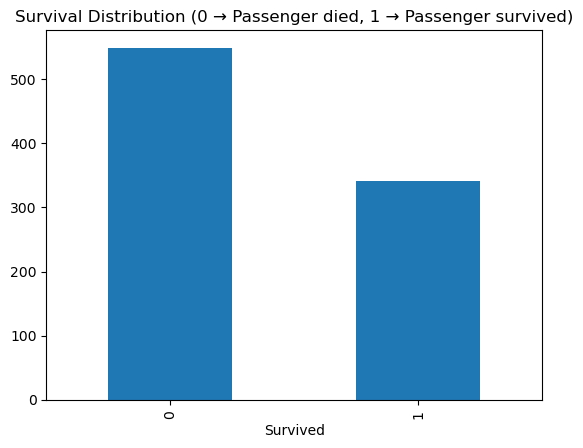

In [123]:

plt.figure()
df['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Distribution (0 → Passenger died, 1 → Passenger survived)')
plt.show()


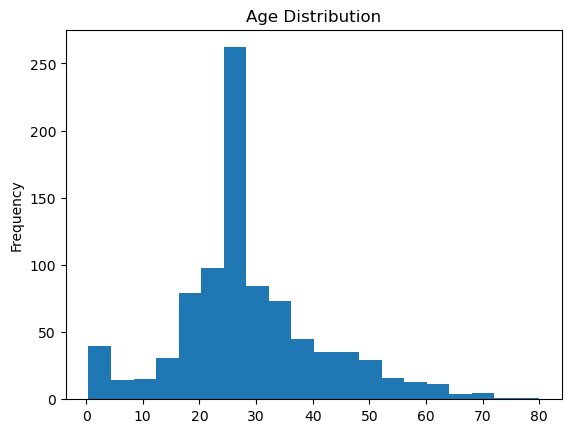

In [124]:

plt.figure()
df['Age'].plot(kind='hist', bins=20)
plt.title('Age Distribution')
plt.show()


## 9. Comparative Analysis

<Figure size 640x480 with 0 Axes>

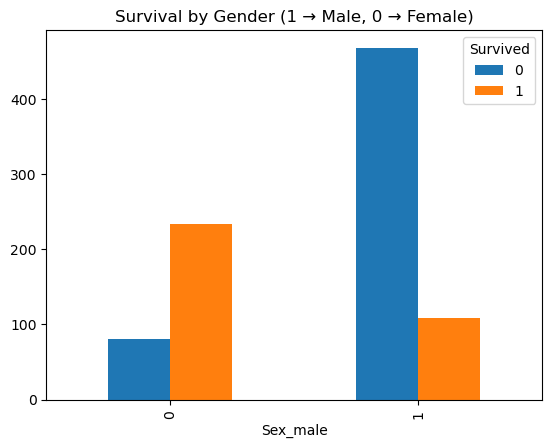

In [128]:

plt.figure()
pd.crosstab(df['Sex_male'], df['Survived']).plot(kind='bar')
plt.title('Survival by Gender (1 → Male, 0 → Female)')
plt.show()


<Figure size 640x480 with 0 Axes>

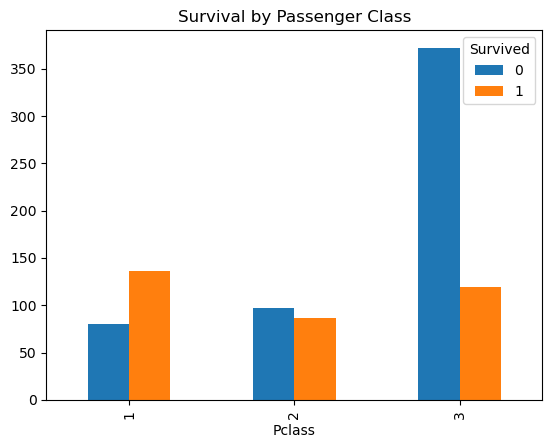

In [129]:

plt.figure()
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')
plt.title('Survival by Passenger Class')
plt.show()


## 10. Multivariate Analysis

In [130]:

pd.crosstab([df['Sex_male'], df['Pclass']], df['Survived'])


Survived           0   1
Sex_male Pclass         
0        1         3  91
         2         6  70
         3        72  72
1        1        77  45
         2        91  17
         3       300  47

## 11. Correlation Analysis

In [131]:

corr = df.corr()
corr.round(2)


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
Survived,1.00,-0.34,-0.06,-0.04,0.08,0.26,-0.54,0.00,-0.15
Pclass,-0.34,1.00,-0.34,0.08,0.02,-0.55,0.13,0.22,0.07
Age,-0.06,-0.34,1.00,-0.23,-0.17,0.10,0.08,-0.03,-0.01
SibSp,-0.04,0.08,-0.23,1.00,0.41,0.16,-0.11,-0.03,0.07
Parch,0.08,0.02,-0.17,0.41,1.00,0.22,-0.25,-0.08,0.06
Fare,0.26,-0.55,0.10,0.16,0.22,1.00,-0.18,-0.12,-0.16
Sex_male,-0.54,0.13,0.08,-0.11,-0.25,-0.18,1.00,-0.07,0.12
Embarked_Q,0.00,0.22,-0.03,-0.03,-0.08,-0.12,-0.07,1.00,-0.50
Embarked_S,-0.15,0.07,-0.01,0.07,0.06,-0.16,0.12,-0.50,1.00


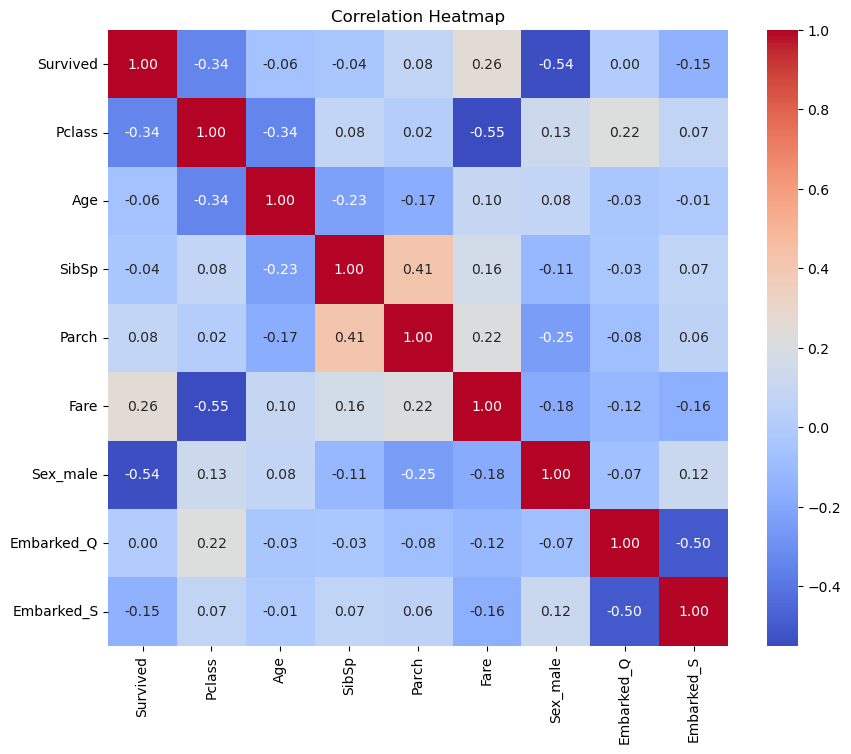

In [132]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), 
            cmap='coolwarm',
            annot=True,        # show numbers
            fmt=".2f")         # 2 decimal places

plt.title('Correlation Heatmap')
plt.show()



## 12. Key Insights

- Gender is the strongest predictor of survival.
- Passenger class significantly influenced survival.
- Higher fare passengers had better survival probability.
- Small families had better survival chances than individuals.
- Survival was structured, not random.
